# ArcFace Loss (Additive Angular Margin Loss)

## Теория ArcFace

В случае с обучением на задачу классификации первая подходящая лосс-функция, которая нам приходит в голову — Cross-Entropy. И на ней действительно можно обучать сеть для распознавания лиц. Но за много лет люди придумали более хитрые трюки, которые делают обучение сети для распознавания лиц более эффективным. Одним из лучших подходов считается ArcFace (Additive Angular Margin).


**Как устроен ArcFace**:

Стандартные SoftMax + кросс-энтропия (CE) выглядят так:

$$L_{CE} = \frac{-1}{N}\sum_1^N \frac{e^{W_{y_i}^{T}x_i + b_{y_i}}}{\sum^n_{j=1}e^{W_j^Tx_i+b_j}},$$

здесь:
- $x_i \in \mathbb{R^d}$ — вектор $i$-го элемента обучающей выборки перед последним полносвязным слоем сети. $y_i$ — класс этого элемента;
- $W_j \in \mathbb{R^d}$ — j-ый столбец матрицы весов последнего слоя сети (т.е. слоя, который производит итоговую классификацю входящего объекта);
- $b_j \in \mathbb{R^d}$ — j-ый элемент вектора байеса последнего слоя сети;
- $N$ — batch size;
- $n$ — количество классов.


Хотя этот лосс работает хорошо, он явным образом не заставляет эмбеддинги $x_i$ элементов, принадлежащих одному классу, быть близкими друг к другу по расстоянию. И не заставляет эмбеддинги элементов, принадлежащих разным классам, быть далеко друг от друга. Все, что хочет этот лосс — чтобы на основе эмбеддингов $x_i$ можно было хорошо классифицировать элементы, никакие ограничений на расстояния между эмбеддингами $x_i$ он не вводит.

Из-за этого у нейросетей для распознавания лиц, которые обучены на обычном CE loss, бывают проблемы с распознаванием лиц, которые сильно отличаются от лиц того же человека разными доп. атрибутами (шляпа/прическа/очки и т.п.). Просто эмбеддинг для таких лиц получается довольно далек по расстоянию от других эмбеддингов лиц этого же человека.

Давайте теперь немного поправим формулу:
- уберем байес последнего слоя, т.е. сделаем $b_j=0$;
- нормализуем веса последнего слоя: ||$W_j$|| = 1;
- нормализуем эмбеддинги: ||$x_i$|| = 1. Перед подачей их на вход последнему слою (т.е. перед умножением на матрицу $W_j$) умножим их на гиперпараметр s. По сути, мы приводим норму всех эмбеддингов к s. Смысл этого гиперпараметра в том, что, возможно, сети проще будет классифицировать эмбеддинги, у которых не единичная норма.

Нормализация приводит к тому, что эмбеддинги распределяются по сфере единичного радиуса (и сфере радиуса s после умножения на гиперпараметр s). И итоговые предсказания сети после последнего слоя зависят только от угла между эмбеддингами $x_i$ и выученных весов $W_j$. От нормы эмбеддинга $x_i$ они больше не зависят, т.к. у всех эмбеддингов они теперь одинаковые.

Получается, в степени экспоненты у нас останется выражение $s W_{y_i}^{T}x_i$, которое можно переписать в виде  $s W_{y_i}^{T}x_i = s ||W_{y_i}||\cdot ||x_i|| \cdot cos\Theta_{y_i}$. Тут $\Theta_{y_i}$ — это угол между векторами $W_{y_i}$ и $x_i$. Но так как мы сделали нормы $W_{y_i}$ и $x_i$ единичными, то все это выражение просто будет равно $s cos\Theta_{y_i}$.

В итоге мы получим следующую формулу лосса:

$$L = \frac{-1}{N}\sum_1^N \frac{e^{s\ cos\Theta_{y_i}}}{e^{s\ cos\Theta_{y_i}} + \sum^n_{j=1,\ j\ne y_i} e^{s\ cos\Theta_j}}$$


И последний шаг. Добавим еще один гиперпараметр $m$. Он называется additive angular margin penalty и заставляет эмбеддинги одного класса быть ближе друг к другу, а эмбеддинги разных классов — более далекими друг от друга.

В итоге получим вот что:

$$L_{ArcFace} = \frac{-1}{N}\sum_1^N \frac{e^{s\ cos(\Theta_{y_i} + m)}}{e^{s\ cos(\Theta_{y_i} + m)} + \sum^n_{j=1,\ j\ne y_i} e^{s\ cos\Theta_j}}$$

Это и есть ArcFace Loss с двумя  гиперпараметрами, s и m.

Получается, что ArcFace Loss завтавляет сеть выучивать эмбеддинги, распределенные по сфере радиуса s, причем чтобы эмбеддинги одного класса были ближе друг к другу, а эмбеддинги разных классов — более далеки друг от друга.

![ArcFace](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTKRR-YA_XR3yhIYBbkc8Zlbua0Q2WdM3gx_g&s)

**Важное пояснение:**

Строго говоря, ArcFace - не лосс, отдельный архитектурный модуль модификация SoftMax. Он реализует идею внесения геометрического отступа непосредственно в пространство признаков. Для обучения в качестве лосса используется обычная кросс-энтропия. Более конкретно по шагам:

1. Вы извлекаете эмбеддинги из бэкбона сети (предобученной модели, у которой обрезан FC-слой, если он был)
2. Эти эмбеддинги поступают в ArcFace-слой, который содержит векторы-центры для каждого класса (веса классификатора) и логику нормализации и добавления углового отступа
3. Для целевого класса ArcFace-слой преобразует косинус угла $\theta$ в $cos(\theta + m)$
4. Для остальных классов оставляет обычный косинус $cos(\theta)$
5. Эти модифицированные логиты подаются на вход стандартной функции Cross-Entropy
6. Градиенты от Cross-Entropy текут назад через ArcFace-слой к бэкбону, обучая модель извлекать эмбеддинги

Результат: модифицированные логиты с "жестким" разделением для целевого класса, а значит и более качественные эмбеддинги.

Схема:
```
[Изображение] → [Бэкбон] → [ЭМБЕДДИНГ] → [ArcFace] → [Логиты] → [CE Loss]
                    │                        │           │          
                   CNN                   Нормализация   Оценки
                                          + Angular    для всех
                                            Margin     классов
```

Для получения качественных эмбеддингов после обучения ArcFace-слой больше не нужен, и его обычно обрезают. Он нужен был только обучения модели, и поэтому часто ArcFace называю именно лоссом. Но стоит всегда держать в голове, что это некоторое упрощение, которое нужно лишь для того, чтобы проще формулировать мысли.

**Доп. литература по ArcFace Loss:**

Оригинальная статья: https://arxiv.org/pdf/1801.07698.pdf

## Другие лоссы

Кроме ArcFace, есть еще много разных вариантов лоссов для задачи Face Recognition. Некоторые из них можно найти, например, [тут](https://openaccess.thecvf.com/content_CVPRW_2020/papers/w48/Hsu_A_Comprehensive_Study_on_Loss_Functions_for_Cross-Factor_Face_Recognition_CVPRW_2020_paper.pdf). Вы можете попробовать реализовать другие лосс-функции в этом проекте в качестве дополнительного задания.

Кроме этого, можно миксовать лосс-функции. Например, обучать нейросеть на сумме ArcFace и TripletLoss. Иногда так выходит лучше, чем если обучать на каком-то одном лоссе.

# Датасет

В качестве датасета нужно использовать картинки из CelebA, выровненные при помощи своей модели из задания 1. Очень желательно их еще кропнуть таким образом, чтобы нейросети поступали на вход преимущественно только лица без какого либо фона, частей тела и прочего.

Если планируете делать дополнительное задание на Identificaton rate metric, то **обязательно разбейте заранее датасет на train/val или train/val/test.** Это нужно сделать не только на уровне кода, а на уровне папок, чтобы точно знать, на каких картинках модель обучалась, а на каких нет. Лучше заранее почитайте [ноутбук с заданием](https://colab.research.google.com/drive/15zuNdOupRFnG7oE-rFj9FsjoNTK6DYn5).

# План заданий

Итак, вот, что от вас требуется в этом задании:

* Выбрать модель (или несколько моделей) для обучения. Можно брать предобученные на ImageNet, но нельзя использовать модели, предобученные на задачу распознавания лиц.
* Обучить эту модель (модели) на CE loss. Добиться accuracy > 0.7.
* Реализовать ArcFace loss.
* Обучить модель (модели) на ArcFace loss. Добиться accuracy > 0.7.
* Написать небольшой отчет по обучению, сравнить CE loss и ArcFace loss.

**P.S. Не забывайте сохранять модели после обучения**

БИБЛИОТЕКИ И ПУТИ

In [ ]:
import pandas as pd
import zipfile
import os
from torch.utils.data import Dataset, DataLoader
import cv2
import shutil
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import numpy as np
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import time
from tqdm import tqdm
from PIL import Image

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
!mkdir -p /content/data
!cp -r /content/drive/MyDrive/FR_project/AlignedDataset/aligned_train_data /content/data/
!cp -r /content/drive/MyDrive/FR_project/AlignedDataset/aligned_val_data /content/data/
!cp /content/drive/MyDrive/FR_project/identity_CelebA.txt /content/data/

In [ ]:
TRAIN_PATH = '/content/data/aligned_train_data'
VAL_PATH = '/content/data/aligned_val_data'
IDENTITY_FILE = '/content/data/identity_CelebA.txt'

ДАТАСЕТЫ И ДАТАЛОАДЕРЫ

In [ ]:
class CelebATrainDataset(Dataset):
    def __init__(self, root_dir, identity_file, transform=None, class_to_idx=None):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []
        self.labels = []

        # Загружаем identity файл
        identities = {}
        with open(identity_file, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 2:
                    filename = parts[0]
                    identity_id = int(parts[1])
                    identities[filename] = identity_id

        # Собираем все изображения в папке
        image_files = [f for f in os.listdir(root_dir)
                       if f.lower().endswith('.jpg')]

        raw_samples = []
        raw_labels = []
        for img_file in image_files:
            if img_file in identities:
                raw_samples.append(os.path.join(root_dir, img_file))
                raw_labels.append(identities[img_file])

        if class_to_idx is None:
            # Строим маппинг с нуля - делаем это ТОЛЬКО для train
            unique_identities = sorted(set(raw_labels))
            self.class_to_idx = {identity: idx for idx, identity in enumerate(unique_identities)}
        else:
            # Используем маппинг, переданный снаружи (для val/test), чтобы
            # индекс класса N означал одного и того же человека и в train,
            # и в val
            self.class_to_idx = class_to_idx

        # Оставляем только сэмплы, чья личность есть в маппинге.
        # Для val это отфильтрует людей, которых модель никогда не видела
        # в train - для них у классификатора просто нет выходного нейрона,
        # и раньше эти сэмплы портили подсчёт accuracy случайными метками.
        for path, identity_id in zip(raw_samples, raw_labels):
            if identity_id in self.class_to_idx:
                self.samples.append(path)
                self.labels.append(self.class_to_idx[identity_id])
        # ===================================================================

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path = self.samples[idx]
        label = self.labels[idx]

        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
class CelebAValidationDataset(Dataset):
    def __init__(self, root_dir, identity_file, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []
        self.identity_ids = []  # Оригинальные ID из файла

        # Загружаем identity файл
        identities = {}
        with open(identity_file, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 2:
                    identities[parts[0]] = int(parts[1])

        # Собираем все изображения
        for img_file in os.listdir(root_dir):
            if img_file.lower().endswith('.jpg') and img_file in identities:
                self.samples.append(os.path.join(root_dir, img_file))
                self.identity_ids.append(identities[img_file])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path = self.samples[idx]
        identity_id = self.identity_ids[idx]  # Оригинальный ID

        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)

        return image, identity_id  # Возвращаем оригинальный ID

In [ ]:
# Для обучения
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Для EfficientNet-B0
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])  # Стандартные для ImageNet
])

# Для валидации (без аугментаций)
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

In [ ]:
train_dataset = CelebATrainDataset(
    TRAIN_PATH,
    IDENTITY_FILE,
    transform=train_transform,
    class_to_idx=None
)

val_dataset = CelebAValidationDataset(
    VAL_PATH,
    IDENTITY_FILE,
    transform=val_transform
)

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    drop_last=True # Для стабильности batch norm
)

In [ ]:
# для классификационной валидации
val_loader = DataLoader(
    val_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    drop_last=False
)

МОДЕЛИ И ЛОССЫ

In [ ]:
class FaceRecognitionModel(nn.Module):
    def __init__(self, embedding_size=512, num_classes=None, dropout_rate=0.4, freeze_layers=0):
        super(FaceRecognitionModel, self).__init__()

        self.backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        self._freeze_early_layers(freeze_first=freeze_layers)

        self.num_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Identity()

        # Embedding head с BatchNorm
        self.embedding = nn.Sequential(
            nn.BatchNorm1d(self.num_features),
            nn.Dropout(dropout_rate),
            nn.Linear(self.num_features, embedding_size),
            nn.BatchNorm1d(embedding_size),
        )

        if num_classes is not None:
            self.classifier = nn.Linear(embedding_size, num_classes)
        else:
            self.classifier = None

        self._initialize_weights()

    def _freeze_early_layers(self, freeze_first=0):
        if freeze_first <= 0:
            print("All layers will be trained")
            return

        layers_to_freeze = []
        if freeze_first >= 1:
            layers_to_freeze.append(self.backbone.features[0])
            print(f"Frozen: features[0] (first Conv2d)")
        for i in range(1, min(freeze_first, 8)):
            if i < len(self.backbone.features):
                layers_to_freeze.append(self.backbone.features[i])
                print(f"Frozen: features[{i}] (MBConv block {i})")
        for layer in layers_to_freeze:
            for param in layer.parameters():
                param.requires_grad = False
        print(f"Total frozen layers: {len(layers_to_freeze)}")

    def _initialize_weights(self):
        for m in self.embedding.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

        if self.classifier is not None:
            nn.init.xavier_uniform_(self.classifier.weight)
            nn.init.constant_(self.classifier.bias, 0)

    def forward(self, x, return_raw=False):
        """
        Forward pass

        Args:
            x: входные изображения
            return_raw: если True, возвращает ненормализованный эмбеддинг для ArcFace

        Returns:
            если return_raw=False: (embedding_norm, logits) или embedding_norm
            если return_raw=True: (embedding_norm, embedding_raw, logits)
        """
        features = self.backbone(x)
        embedding_raw = self.embedding(features)
        embedding_norm = F.normalize(embedding_raw, p=2, dim=1)

        if self.classifier is not None:
            logits = self.classifier(embedding_norm)
            if return_raw:
                return embedding_norm, embedding_raw, logits
            return embedding_norm, logits
        else:
            return embedding_norm

    def get_embedding(self, x):
        self.eval()
        with torch.no_grad():
            features = self.backbone(x)
            embedding_raw = self.embedding(features)
            embedding_norm = F.normalize(embedding_raw, p=2, dim=1)
            return embedding_norm

In [ ]:
class ArcFaceLoss(nn.Module):
    def __init__(self, in_features, out_features, s=30.0, m=0.5):
        super(ArcFaceLoss, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.s = s
        self.m = m

        # Предвычисляем тригонометрические значения
        self.cos_m = torch.cos(torch.tensor(m))
        self.sin_m = torch.sin(torch.tensor(m))

        # Веса классификатора
        self.weight = nn.Parameter(torch.FloatTensor(out_features, in_features))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, embeddings, labels):
        # Нормализация эмбеддингов и весов
        embeddings = F.normalize(embeddings, p=2, dim=1)
        weight = F.normalize(self.weight, p=2, dim=1)

        # Косинусное сходство
        cosine = F.linear(embeddings, weight)

        # КЛИППИНГ - критически важно для численной стабильности
        cosine = torch.clamp(cosine, -1.0 + 1e-7, 1.0 - 1e-7)

        # Создаем one-hot маску
        one_hot = torch.zeros_like(cosine)
        one_hot.scatter_(1, labels.view(-1, 1).long(), 1)

        # ArcFace: cos(θ + m) = cos(θ)*cos(m) - sin(θ)*sin(m)
        sine = torch.sqrt(1.0 - cosine ** 2)
        phi = cosine * self.cos_m - sine * self.sin_m

        # Для правильных классов используем phi, для остальных - cosine
        logits = torch.where(one_hot == 1, phi, cosine)

        # Масштабирование
        logits *= self.s

        return logits

ФУНКЦИИ ОБУЧЕНИЯ

In [ ]:
def train_epoch(model, dataloader, optimizer, criterion, device,
                use_arcface=False, scaler=None):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    progress_bar = tqdm(dataloader, desc='Training')
    for batch_idx, (images, labels) in enumerate(progress_bar):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        if use_arcface:
            # Получаем нормализованный эмбеддинг для ArcFace
            embedding_norm, _, _ = model(images, return_raw=True)
            # ArcFaceLoss возвращает логиты с margin
            logits = criterion(embedding_norm, labels)
            # Считаем кросс-энтропию на логитах
            loss = F.cross_entropy(logits, labels)
        else:
            # Для CE: просто forward
            _, logits = model(images)
            loss = criterion(logits, labels)

        if scaler is not None:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        total_loss += loss.item()
        _, predicted = logits.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        progress_bar.set_postfix({
            'Loss': f'{total_loss/(batch_idx+1):.4f}',
            'Acc': f'{100.*correct/total:.2f}%'
        })

    return total_loss / len(dataloader), correct / total

In [ ]:
def validate_classification(model, dataloader, criterion, device, use_arcface=False):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        progress_bar = tqdm(dataloader, desc='Validation')
        for images, labels in progress_bar:
            images, labels = images.to(device), labels.to(device)

            if use_arcface:
                embedding_norm, _, _ = model(images, return_raw=True)
                logits = criterion(embedding_norm, labels)
                loss = F.cross_entropy(logits, labels)
            else:
                _, logits = model(images)
                loss = criterion(logits, labels)

            total_loss += loss.item()
            _, predicted = logits.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            progress_bar.set_postfix({
                'Loss': f'{total_loss/len(dataloader):.4f}',
                'Acc': f'{100.*correct/total:.2f}%'
            })

    return total_loss / len(dataloader), correct / total

In [ ]:
def compute_verification_accuracy(model, val_dataset, device, threshold=0.5):
    """
    Вычисляет verification accuracy на валидационном датасете
    Использует ВСЕ возможные пары для стабильной оценки
    """
    model.eval()

    val_loader = DataLoader(
        val_dataset,
        batch_size=128,
        shuffle=False,
        num_workers=0,
        pin_memory=False
    )

    all_embeddings = []
    all_person_ids = []

    with torch.no_grad():
        for images, person_ids in tqdm(val_loader, desc='Extracting embeddings'):
            images = images.to(device)
            embeddings = model.get_embedding(images)
            all_embeddings.append(embeddings.cpu())
            all_person_ids.extend(person_ids.numpy())

    all_embeddings = torch.cat(all_embeddings, dim=0)
    all_person_ids = np.array(all_person_ids)

    # Группируем индексы по person_id
    person_to_indices = {}
    for idx, person_id in enumerate(all_person_ids):
        if person_id not in person_to_indices:
            person_to_indices[person_id] = []
        person_to_indices[person_id].append(idx)

    # Положительные пары (same): все комбинации для каждого человека
    same_pairs = []
    for indices in person_to_indices.values():
        if len(indices) >= 2:
            for i in range(len(indices)):
                for j in range(i + 1, len(indices)):
                    same_pairs.append((indices[i], indices[j]))

    # Отрицательные пары (diff): столько же, сколько положительных
    diff_pairs = []
    person_ids = list(person_to_indices.keys())
    num_diff_needed = len(same_pairs)

    # Генерируем отрицательные пары случайно, но сбалансированно
    attempts = 0
    max_attempts = num_diff_needed * 10
    while len(diff_pairs) < num_diff_needed and attempts < max_attempts:
        attempts += 1
        p1, p2 = np.random.choice(person_ids, size=2, replace=False)
        idx1 = np.random.choice(person_to_indices[p1])
        idx2 = np.random.choice(person_to_indices[p2])
        diff_pairs.append((idx1, idx2))

    # Если не хватило, добираем случайными
    while len(diff_pairs) < num_diff_needed:
        p1, p2 = np.random.choice(person_ids, size=2, replace=False)
        idx1 = np.random.choice(person_to_indices[p1])
        idx2 = np.random.choice(person_to_indices[p2])
        diff_pairs.append((idx1, idx2))

    print(f"Positive pairs (same): {len(same_pairs)}")
    print(f"Negative pairs (diff): {len(diff_pairs)}")
    print(f"Total pairs: {len(same_pairs) + len(diff_pairs)}")

    # Оценка для заданного порога
    def evaluate_pairs(pairs, expected_same):
        correct = 0
        for idx1, idx2 in pairs:
            emb1 = all_embeddings[idx1]
            emb2 = all_embeddings[idx2]
            similarity = F.cosine_similarity(emb1.unsqueeze(0), emb2.unsqueeze(0)).item()
            predicted_same = similarity > threshold
            if predicted_same == expected_same:
                correct += 1
        return correct

    same_correct = evaluate_pairs(same_pairs, True)
    diff_correct = evaluate_pairs(diff_pairs, False)

    accuracy = (same_correct + diff_correct) / (len(same_pairs) + len(diff_pairs))

    # Поиск оптимального порога
    best_threshold = threshold
    best_acc = accuracy

    thresholds = np.linspace(0.3, 0.8, 20)
    for thresh in thresholds:
        same_correct_t = evaluate_pairs(same_pairs, True)
        diff_correct_t = evaluate_pairs(diff_pairs, False)
        acc_t = (same_correct_t + diff_correct_t) / (len(same_pairs) + len(diff_pairs))
        if acc_t > best_acc:
            best_acc = acc_t
            best_threshold = thresh

    return accuracy, best_threshold

In [ ]:
def plot_training_progress(train_losses, train_accs, verification_accs, epoch):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # График 1: Loss
    axes[0].plot(train_losses, label='Train Loss', color='blue', linewidth=2)
    axes[0].set_title('Training Loss', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # График 2: Verification Accuracy
    axes[1].plot(verification_accs, label='Verification Acc', color='green', linewidth=2)
    axes[1].set_title('Verification Accuracy', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].axhline(y=0.7, color='red', linestyle='--', linewidth=2, label='Target 0.7')
    axes[1].legend()

    # Лучший результат
    if verification_accs:
        best_acc = max(verification_accs)
        best_epoch = verification_accs.index(best_acc)
        axes[1].scatter(best_epoch, best_acc, color='red', s=100,
                       zorder=5, label=f'Best: {best_acc:.4f}')
        axes[1].legend()

    plt.suptitle(f'Training Progress - Epoch {epoch}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [ ]:
def train(model, train_loader, val_dataset, device,
          epochs=50, lr=0.001, weight_decay=1e-4,
          loss_type='ce', embedding_size=512,
          save_dir='/content/drive/MyDrive/FR_project', model_name='face_model'):

    # Создаем criterion
    if loss_type == 'arcface':
        num_classes = len(train_loader.dataset.class_to_idx)
        criterion = ArcFaceLoss(
            in_features=embedding_size,
            out_features=num_classes,
            s=30.0,
            m=0.3
        ).to(device)
        use_arcface = True

        # 1. Меняем оптимизатор на Adam
        optimizer = optim.SGD([
            {'params': model.backbone.parameters(), 'lr': 0.01, 'momentum': 0.9},
            {'params': model.embedding.parameters(), 'lr': 0.01, 'momentum': 0.9},
            {'params': criterion.parameters(), 'lr': 0.01, 'momentum': 0.9}  # Добавляем веса ArcFace
        ], weight_decay=1e-4)

    else:
        num_classes = len(train_loader.dataset.class_to_idx)
        criterion = nn.CrossEntropyLoss()
        use_arcface = False

        optimizer = optim.SGD([
            {'params': model.backbone.parameters(), 'lr': 0.1, 'momentum': 0.9},
            {'params': model.embedding.parameters(), 'lr': 0.01, 'momentum': 0.9},
            {'params': model.classifier.parameters(), 'lr': 0.01, 'momentum': 0.9}
        ], weight_decay=1e-4)

        print(f"Using Cross Entropy Loss with {num_classes} classes")

    #scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    # Смешанная точность
    scaler = torch.amp.GradScaler('cuda') if torch.cuda.is_available() else None

    # Логирование
    train_losses = []
    train_accs = []
    verification_accs = []
    best_ver_acc = 0
    best_model_state = None

    # Создаем директорию для сохранения
    os.makedirs(save_dir, exist_ok=True)

    for epoch in range(epochs):
        print(f"\n{'='*50}")
        print(f"Epoch {epoch+1}/{epochs}")
        print(f"{'='*50}")

        # Обучение
        train_loss, train_acc = train_epoch(
            model, train_loader, optimizer, criterion, device,
            use_arcface=use_arcface, scaler=scaler
        )

        # Verification accuracy
        ver_acc, best_threshold = compute_verification_accuracy(
            model, val_dataset, device, threshold=0.5
        )

        # Сохраняем метрики
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        verification_accs.append(ver_acc)

        print(f"\nResults:")
        print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
        print(f"  Verification Acc: {ver_acc:.4f} (threshold: {best_threshold:.3f})")

        # Scheduler
        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']
        print(f"  Learning Rate: {current_lr:.6f}")

        # Сохраняем лучшую модель
        if ver_acc > best_ver_acc:
            best_ver_acc = ver_acc

            best_model_state = {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'ver_acc': ver_acc,
                'train_loss': train_loss,
                'train_acc': train_acc,
                'embedding_size': embedding_size,
                'loss_type': loss_type,
                'best_threshold': best_threshold
            }

            if loss_type == 'arcface':
                best_model_state['arcface_weight'] = criterion.weight.data
                best_model_state['arcface_s'] = criterion.s
                best_model_state['arcface_m'] = criterion.m

            print(f"  New best model with Ver Acc: {ver_acc:.4f}")

        # Визуализация каждые 5 эпох
        if (epoch + 1) % 5 == 0 or epoch == epochs - 1:
            plot_training_progress(
                train_losses, [], verification_accs,
                epoch + 1
            )

    # Сохраняем лучшую модель
    if best_model_state is not None:
        torch.save(best_model_state, f'{save_dir}/best_{model_name}.pth')
        print(f"\nBest model saved to: {save_dir}/best_{model_name}.pth")
        print(f"Best Verification Accuracy: {best_ver_acc:.4f} at epoch {best_model_state['epoch'] + 1}")

    # Сохраняем финальную модель (только эмбеддинги для инференса)
    final_model = FaceRecognitionModel(
        embedding_size=embedding_size,
        num_classes=None,  # Без классификатора
        dropout_rate=0.0,
        freeze_layers=0
    ).to(device)

    final_state_dict = {}
    for key, value in best_model_state['model_state_dict'].items():
        # Пропускаем classifier веса
        if not key.startswith('classifier.'):
            final_state_dict[key] = value

    final_model.load_state_dict(final_state_dict, strict=False)

    torch.save({
        'model_state_dict': final_model.state_dict(),
        'embedding_size': embedding_size,
        'input_size': (224, 224),
        'loss_type': loss_type,
        'ver_acc': best_ver_acc,
        'class_to_idx': train_loader.dataset.class_to_idx,
        'best_threshold': best_model_state.get('best_threshold', 0.5)
    }, f'{save_dir}/final_{model_name}.pth')

    print(f"Final inference model saved to: {save_dir}/final_{model_name}.pth")

    print(f"\n{'='*60}")
    print(f"Training complete")
    print(f"{'='*60}")
    print(f"Best Verification Accuracy: {best_ver_acc:.4f}")

    return model, train_losses, train_accs, verification_accs

ПРОСТО CE LOSS

In [ ]:
# Создаем модель
num_classes = len(train_dataset.class_to_idx)

model = FaceRecognitionModel(
    embedding_size=512,
    num_classes=num_classes,
    dropout_rate=0.4,
    freeze_layers=0
).to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 138MB/s]


All layers will be trained


Using Cross Entropy Loss with 1000 classes

Epoch 1/30


Extracting embeddings: 100%|██████████| 16/16 [00:08<00:00,  1.83it/s]


Positive pairs (same): 4000
Negative pairs (diff): 4000
Total pairs: 8000

Results:
  Train Loss: 6.9061, Train Acc: 0.0011
  Verification Acc: 0.5146 (threshold: 0.500)
  Learning Rate: 0.100000
  New best model with Ver Acc: 0.5146

Epoch 2/30


Extracting embeddings: 100%|██████████| 16/16 [00:08<00:00,  1.99it/s]


Positive pairs (same): 4000
Negative pairs (diff): 4000
Total pairs: 8000

Results:
  Train Loss: 6.8912, Train Acc: 0.0049
  Verification Acc: 0.5989 (threshold: 0.500)
  Learning Rate: 0.100000
  New best model with Ver Acc: 0.5989

Epoch 3/30


...

Positive pairs (same): 4000
Negative pairs (diff): 4000
Total pairs: 8000

Results:
  Train Loss: 6.8682, Train Acc: 0.0175
  Verification Acc: 0.6846 (threshold: 0.500)
  Learning Rate: 0.100000
  New best model with Ver Acc: 0.6846

Epoch 4/30


Extracting embeddings: 100%|██████████| 16/16 [00:07<00:00,  2.05it/s]


Positive pairs (same): 4000
Negative pairs (diff): 4000
Total pairs: 8000

Results:
  Train Loss: 6.8454, Train Acc: 0.0402
  Verification Acc: 0.7304 (threshold: 0.500)
  Learning Rate: 0.100000
  New best model with Ver Acc: 0.7304

Epoch 5/30


Extracting embeddings: 100%|██████████| 16/16 [00:08<00:00,  1.81it/s]


Positive pairs (same): 4000
Negative pairs (diff): 4000
Total pairs: 8000

Results:
  Train Loss: 6.8241, Train Acc: 0.0705
  Verification Acc: 0.7570 (threshold: 0.500)
  Learning Rate: 0.100000
  New best model with Ver Acc: 0.7570


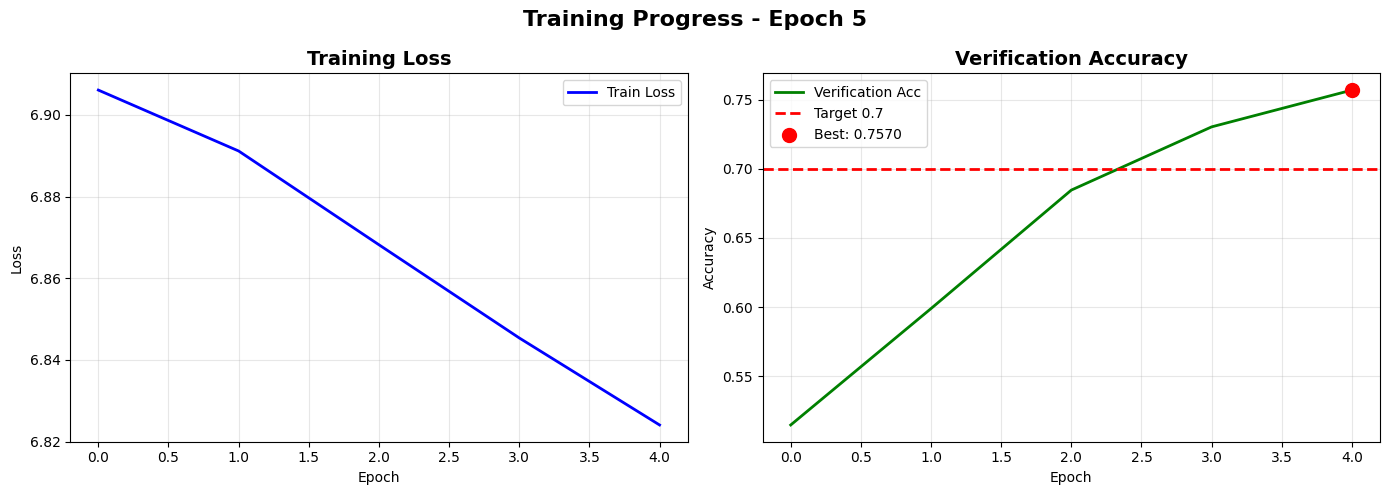


Epoch 6/30


Extracting embeddings: 100%|██████████| 16/16 [00:08<00:00,  1.92it/s]


Positive pairs (same): 4000
Negative pairs (diff): 4000
Total pairs: 8000

Results:
  Train Loss: 6.8027, Train Acc: 0.1122
  Verification Acc: 0.7760 (threshold: 0.500)
  Learning Rate: 0.100000
  New best model with Ver Acc: 0.7760

Epoch 7/30


Extracting embeddings: 100%|██████████| 16/16 [00:08<00:00,  1.93it/s]


Positive pairs (same): 4000
Negative pairs (diff): 4000
Total pairs: 8000

Results:
  Train Loss: 6.7812, Train Acc: 0.1543
  Verification Acc: 0.7909 (threshold: 0.500)
  Learning Rate: 0.100000
  New best model with Ver Acc: 0.7909

Epoch 8/30


...

Positive pairs (same): 4000
Negative pairs (diff): 4000
Total pairs: 8000

Results:
  Train Loss: 6.7599, Train Acc: 0.1999
  Verification Acc: 0.7990 (threshold: 0.500)
  Learning Rate: 0.100000
  New best model with Ver Acc: 0.7990

Epoch 9/30


Extracting embeddings: 100%|██████████| 16/16 [00:08<00:00,  1.99it/s]


Positive pairs (same): 4000
Negative pairs (diff): 4000
Total pairs: 8000

Results:
  Train Loss: 6.7381, Train Acc: 0.2450
  Verification Acc: 0.8105 (threshold: 0.500)
  Learning Rate: 0.100000
  New best model with Ver Acc: 0.8105

Epoch 10/30


Extracting embeddings: 100%|██████████| 16/16 [00:08<00:00,  1.83it/s]


Positive pairs (same): 4000
Negative pairs (diff): 4000
Total pairs: 8000

Results:
  Train Loss: 6.7163, Train Acc: 0.2907
  Verification Acc: 0.8174 (threshold: 0.500)
  Learning Rate: 0.100000
  New best model with Ver Acc: 0.8174


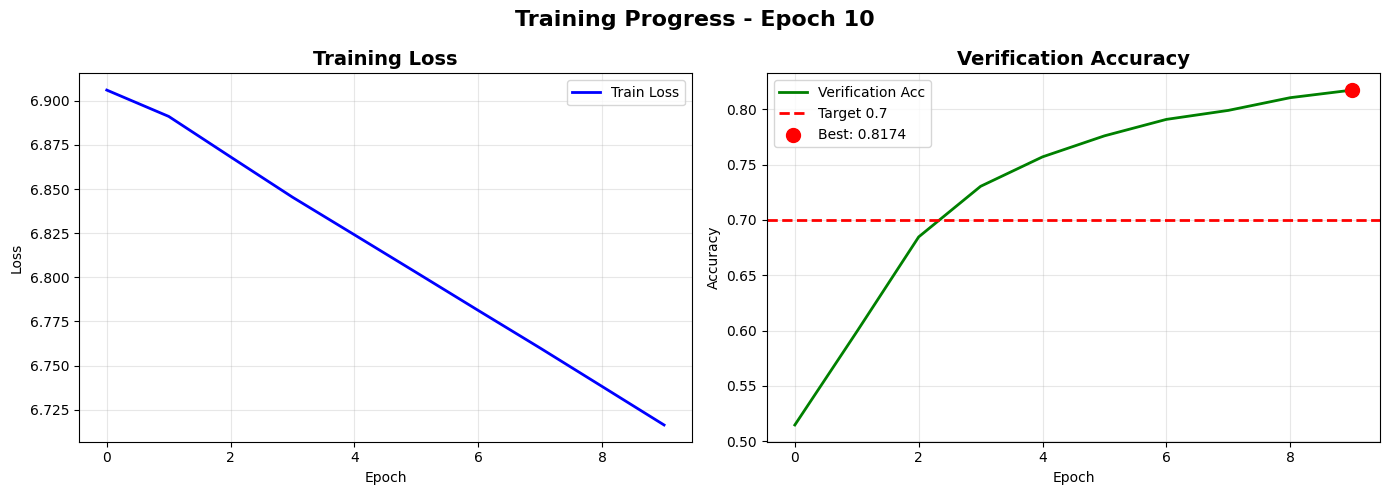


Epoch 11/30


Extracting embeddings: 100%|██████████| 16/16 [00:07<00:00,  2.08it/s]


Positive pairs (same): 4000
Negative pairs (diff): 4000
Total pairs: 8000

Results:
  Train Loss: 6.6939, Train Acc: 0.3392
  Verification Acc: 0.8241 (threshold: 0.500)
  Learning Rate: 0.100000
  New best model with Ver Acc: 0.8241

Epoch 12/30


Extracting embeddings: 100%|██████████| 16/16 [00:08<00:00,  1.82it/s]


Positive pairs (same): 4000
Negative pairs (diff): 4000
Total pairs: 8000

Results:
  Train Loss: 6.6723, Train Acc: 0.3712
  Verification Acc: 0.8254 (threshold: 0.500)
  Learning Rate: 0.100000
  New best model with Ver Acc: 0.8254

Epoch 13/30


...

Positive pairs (same): 4000
Negative pairs (diff): 4000
Total pairs: 8000

Results:
  Train Loss: 6.6502, Train Acc: 0.4103
  Verification Acc: 0.8267 (threshold: 0.500)
  Learning Rate: 0.100000
  New best model with Ver Acc: 0.8267

Epoch 14/30


Extracting embeddings: 100%|██████████| 16/16 [00:08<00:00,  1.95it/s]


Positive pairs (same): 4000
Negative pairs (diff): 4000
Total pairs: 8000

Results:
  Train Loss: 6.6284, Train Acc: 0.4449
  Verification Acc: 0.8319 (threshold: 0.500)
  Learning Rate: 0.100000
  New best model with Ver Acc: 0.8319

Epoch 15/30


Extracting embeddings: 100%|██████████| 16/16 [00:08<00:00,  1.82it/s]


Positive pairs (same): 4000
Negative pairs (diff): 4000
Total pairs: 8000

Results:
  Train Loss: 6.6061, Train Acc: 0.4777
  Verification Acc: 0.8393 (threshold: 0.500)
  Learning Rate: 0.100000
  New best model with Ver Acc: 0.8393


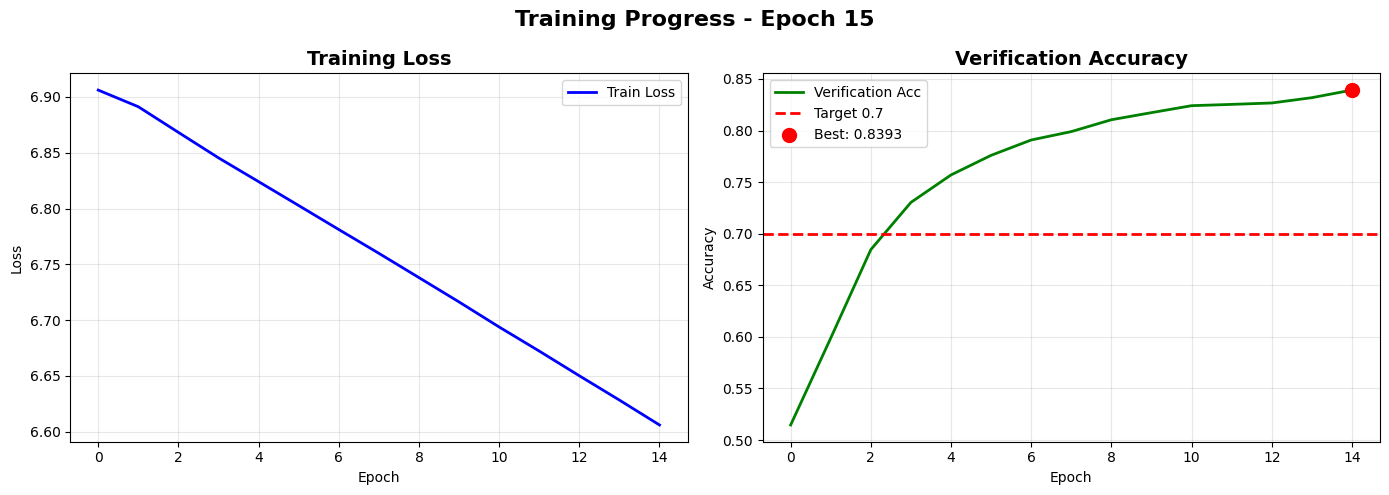


Epoch 16/30


Extracting embeddings: 100%|██████████| 16/16 [00:07<00:00,  2.04it/s]


Positive pairs (same): 4000
Negative pairs (diff): 4000
Total pairs: 8000

Results:
  Train Loss: 6.5835, Train Acc: 0.5187
  Verification Acc: 0.8349 (threshold: 0.500)
  Learning Rate: 0.100000

Epoch 17/30


Extracting embeddings: 100%|██████████| 16/16 [00:08<00:00,  1.85it/s]


Positive pairs (same): 4000
Negative pairs (diff): 4000
Total pairs: 8000

Results:
  Train Loss: 6.5616, Train Acc: 0.5398
  Verification Acc: 0.8511 (threshold: 0.500)
  Learning Rate: 0.100000
  New best model with Ver Acc: 0.8511

Epoch 18/30


...

Positive pairs (same): 4000
Negative pairs (diff): 4000
Total pairs: 8000

Results:
  Train Loss: 6.5391, Train Acc: 0.5681
  Verification Acc: 0.8421 (threshold: 0.500)
  Learning Rate: 0.100000

Epoch 19/30


Extracting embeddings: 100%|██████████| 16/16 [00:07<00:00,  2.04it/s]


Positive pairs (same): 4000
Negative pairs (diff): 4000
Total pairs: 8000

Results:
  Train Loss: 6.5166, Train Acc: 0.5930
  Verification Acc: 0.8492 (threshold: 0.500)
  Learning Rate: 0.100000

Epoch 20/30


Extracting embeddings: 100%|██████████| 16/16 [00:08<00:00,  1.86it/s]


Positive pairs (same): 4000
Negative pairs (diff): 4000
Total pairs: 8000

Results:
  Train Loss: 6.4937, Train Acc: 0.6180
  Verification Acc: 0.8429 (threshold: 0.500)
  Learning Rate: 0.100000


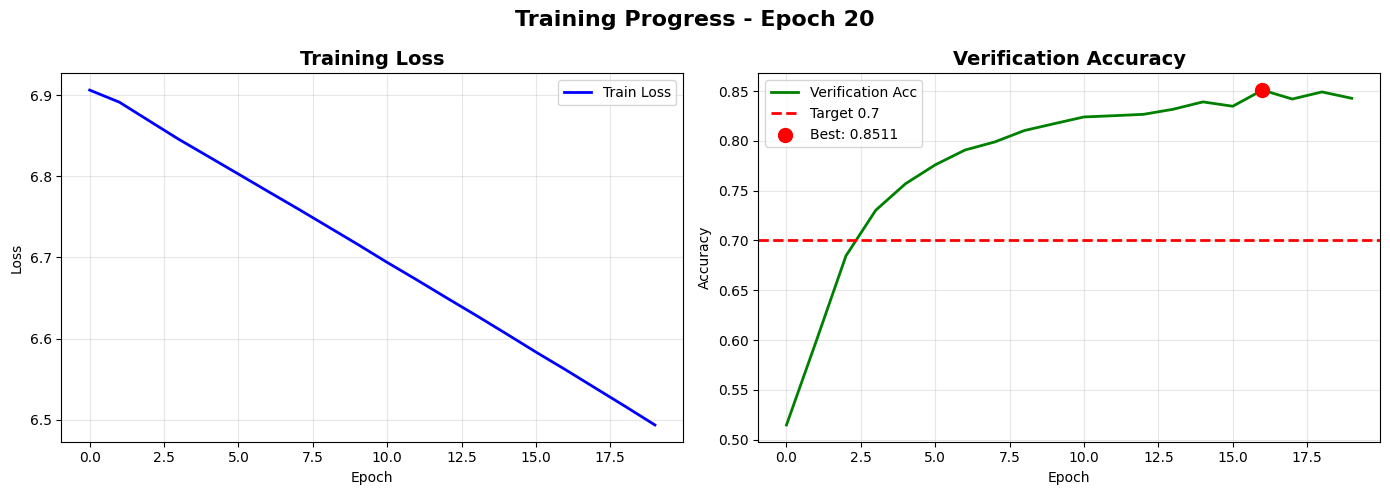


Epoch 21/30


Extracting embeddings: 100%|██████████| 16/16 [00:08<00:00,  1.91it/s]


Positive pairs (same): 4000
Negative pairs (diff): 4000
Total pairs: 8000

Results:
  Train Loss: 6.4713, Train Acc: 0.6317
  Verification Acc: 0.8514 (threshold: 0.500)
  Learning Rate: 0.100000
  New best model with Ver Acc: 0.8514

Epoch 22/30


Extracting embeddings: 100%|██████████| 16/16 [00:08<00:00,  1.89it/s]


Positive pairs (same): 4000
Negative pairs (diff): 4000
Total pairs: 8000

Results:
  Train Loss: 6.4501, Train Acc: 0.6514
  Verification Acc: 0.8496 (threshold: 0.500)
  Learning Rate: 0.100000

Epoch 23/30


...

Positive pairs (same): 4000
Negative pairs (diff): 4000
Total pairs: 8000

Results:
  Train Loss: 6.4284, Train Acc: 0.6655
  Verification Acc: 0.8366 (threshold: 0.500)
  Learning Rate: 0.100000

Epoch 24/30


Extracting embeddings: 100%|██████████| 16/16 [00:08<00:00,  1.88it/s]


Positive pairs (same): 4000
Negative pairs (diff): 4000
Total pairs: 8000

Results:
  Train Loss: 6.4058, Train Acc: 0.6852
  Verification Acc: 0.8450 (threshold: 0.500)
  Learning Rate: 0.100000

Epoch 25/30


Extracting embeddings: 100%|██████████| 16/16 [00:08<00:00,  1.94it/s]


Positive pairs (same): 4000
Negative pairs (diff): 4000
Total pairs: 8000

Results:
  Train Loss: 6.3847, Train Acc: 0.6964
  Verification Acc: 0.8575 (threshold: 0.500)
  Learning Rate: 0.100000
  New best model with Ver Acc: 0.8575


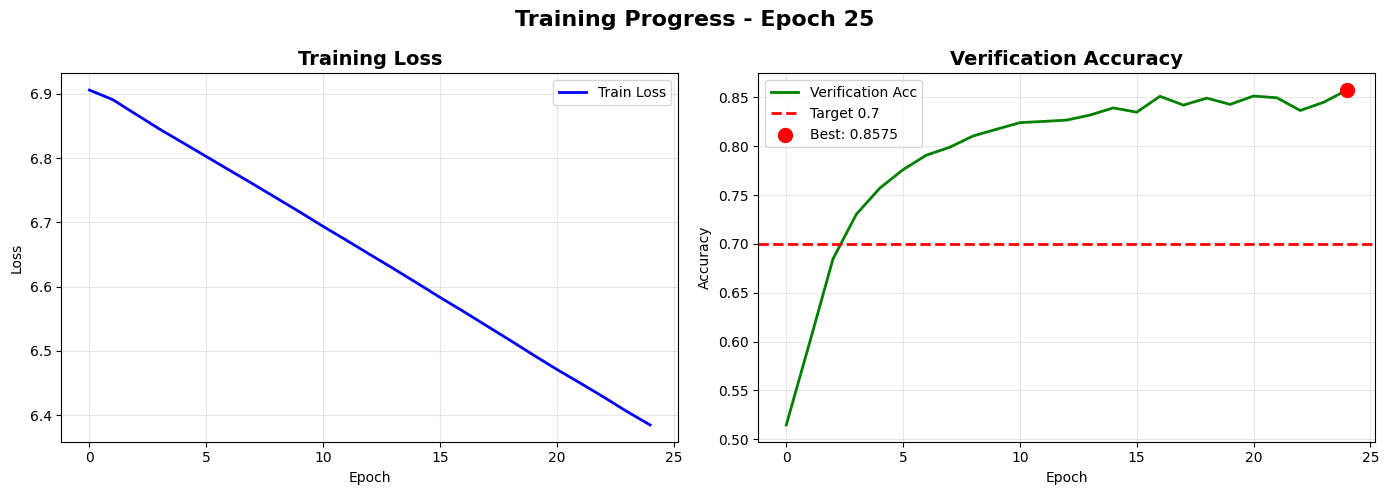


Epoch 26/30


Extracting embeddings: 100%|██████████| 16/16 [00:08<00:00,  1.83it/s]


Positive pairs (same): 4000
Negative pairs (diff): 4000
Total pairs: 8000

Results:
  Train Loss: 6.3621, Train Acc: 0.7112
  Verification Acc: 0.8456 (threshold: 0.500)
  Learning Rate: 0.100000

Epoch 27/30


Extracting embeddings: 100%|██████████| 16/16 [00:08<00:00,  1.92it/s]


Positive pairs (same): 4000
Negative pairs (diff): 4000
Total pairs: 8000

Results:
  Train Loss: 6.3410, Train Acc: 0.7218
  Verification Acc: 0.8500 (threshold: 0.500)
  Learning Rate: 0.100000

Epoch 28/30


...

Positive pairs (same): 4000
Negative pairs (diff): 4000
Total pairs: 8000

Results:
  Train Loss: 6.3200, Train Acc: 0.7324
  Verification Acc: 0.8440 (threshold: 0.500)
  Learning Rate: 0.100000

Epoch 29/30


Extracting embeddings: 100%|██████████| 16/16 [00:08<00:00,  1.83it/s]


Positive pairs (same): 4000
Negative pairs (diff): 4000
Total pairs: 8000

Results:
  Train Loss: 6.2992, Train Acc: 0.7397
  Verification Acc: 0.8456 (threshold: 0.500)
  Learning Rate: 0.100000

Epoch 30/30


Extracting embeddings: 100%|██████████| 16/16 [00:07<00:00,  2.03it/s]


Positive pairs (same): 4000
Negative pairs (diff): 4000
Total pairs: 8000

Results:
  Train Loss: 6.2774, Train Acc: 0.7470
  Verification Acc: 0.8360 (threshold: 0.500)
  Learning Rate: 0.100000


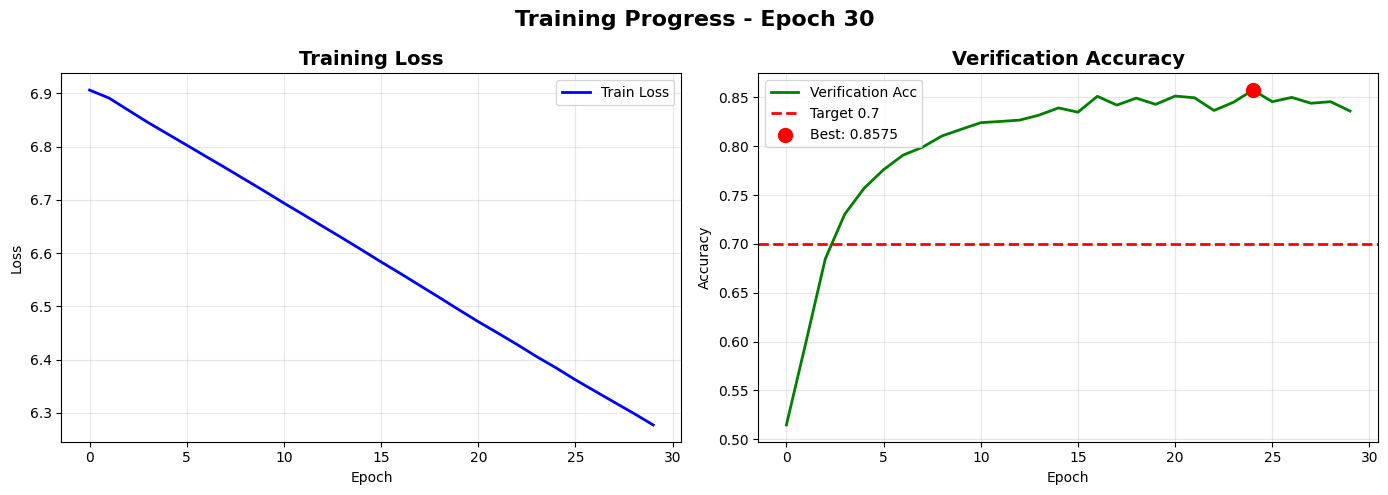


Best model saved to: /content/drive/MyDrive/best_face_model_ce.pth
Best Verification Accuracy: 0.8575 at epoch 25
All layers will be trained
Final inference model saved to: /content/drive/MyDrive/final_face_model_ce.pth

Training complete
Best Verification Accuracy: 0.8575


In [ ]:
model_ce, train_losses_ce, train_accs_ce, ver_accs_ce = train(
    model=model,
    train_loader=train_loader,
    val_dataset=val_dataset,
    device=device,
    epochs=30,
    lr=0.001,  # Базовый lr для embedding и classifier
    weight_decay=1e-4,
    loss_type='ce',
    embedding_size=512,
    save_dir='/content/drive/MyDrive/FR_project',
    model_name='face_model_ce'
)

ПРОВЕРКИ ПОСЛЕ СЕ

In [ ]:
def analyze_similarities(model, val_dataset, device, num_pairs=1000):
    """Анализ распределения сходств"""
    model.eval()

    val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

    all_embeddings = []
    all_person_ids = []

    with torch.no_grad():
        for images, person_ids in val_loader:
            images = images.to(device)
            embeddings = model.get_embedding(images)
            all_embeddings.append(embeddings.cpu())
            all_person_ids.extend(person_ids.numpy())

    all_embeddings = torch.cat(all_embeddings, dim=0)
    all_person_ids = np.array(all_person_ids)

    same_similarities = []
    diff_similarities = []

    for _ in range(num_pairs):
        idx1 = np.random.randint(0, len(all_embeddings))
        idx2 = np.random.randint(0, len(all_embeddings))

        emb1 = all_embeddings[idx1]
        emb2 = all_embeddings[idx2]
        similarity = F.cosine_similarity(emb1.unsqueeze(0), emb2.unsqueeze(0)).item()

        if all_person_ids[idx1] == all_person_ids[idx2]:
            same_similarities.append(similarity)
        else:
            diff_similarities.append(similarity)

    # Статистика
    print(f"Same person similarities:")
    print(f"  mean={np.mean(same_similarities):.4f}")
    print(f"  std={np.std(same_similarities):.4f}")
    print(f"  min={np.min(same_similarities):.4f}")
    print(f"  max={np.max(same_similarities):.4f}")
    print(f"\nDifferent persons similarities:")
    print(f"  mean={np.mean(diff_similarities):.4f}")
    print(f"  std={np.std(diff_similarities):.4f}")
    print(f"  min={np.min(diff_similarities):.4f}")
    print(f"  max={np.max(diff_similarities):.4f}")
    print(f"\nSeparation (same - diff): {np.mean(same_similarities) - np.mean(diff_similarities):.4f}")

    # Критерии хорошего обучения:
    if np.mean(same_similarities) - np.mean(diff_similarities) > 0.3:
        print("GOOD: Embeddings are well separated!")
    elif np.mean(same_similarities) - np.mean(diff_similarities) > 0.1:
        print("OK: Embeddings are somewhat separated, need more training")
    else:
        print("BAD: Embeddings are not separated - model is not learning!")

# Запустите после 5 эпох
analyze_similarities(model_ce, val_dataset, device)

Same person similarities:
  mean=0.8659
  std=0.1513
  min=0.6544
  max=1.0000

Different persons similarities:
  mean=0.0464
  std=0.3171
  min=-0.6249
  max=0.8691

Separation (same - diff): 0.8195
GOOD: Embeddings are well separated!


In [ ]:
# Эта проверка может иногда перемешивать кластеры
# здесь результат отображается в 2-мерном пространстве
# что не может передать сложность 512-мерного пространства
# в нем точки разделены гораздо лучше

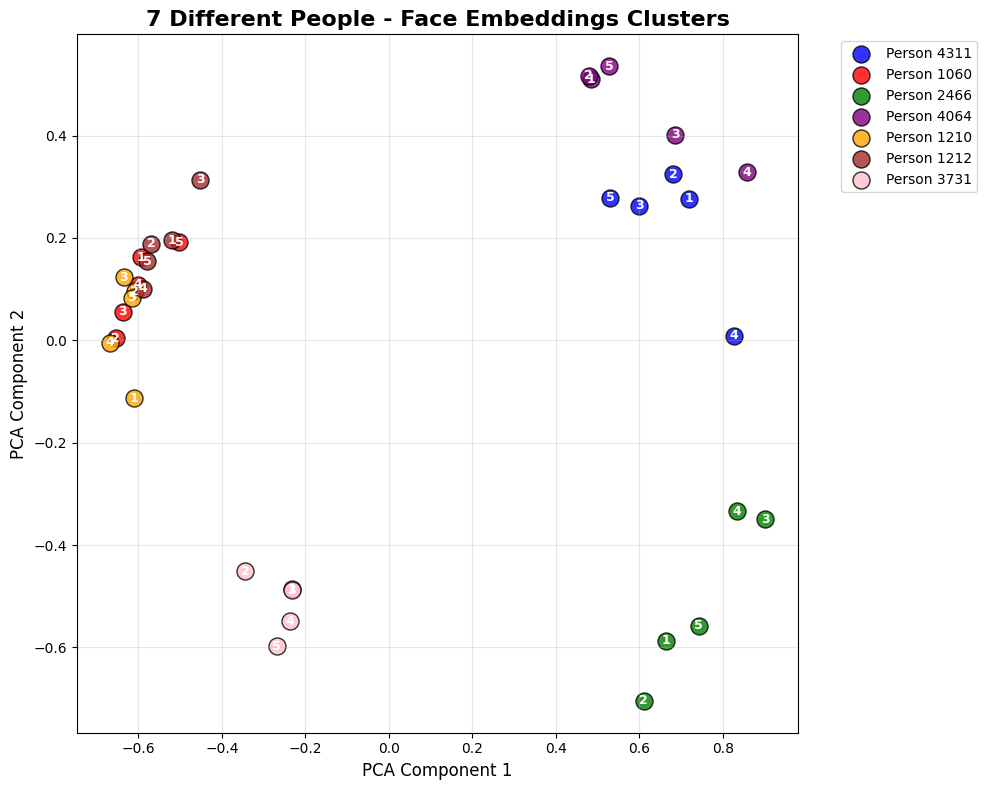


Each color = one person, numbers = different photos of that person
Same person = points of same color cluster together
Different people = points of different colors are separated


In [ ]:
def show_face_clusters(model, val_dataset, device, num_persons=7, images_per_person=5):
    model.eval()

    # Выбираем 7 случайных людей из валидации
    person_to_indices = {}
    for idx, (_, person_id) in enumerate(val_dataset):
        if person_id not in person_to_indices:
            person_to_indices[person_id] = []
        person_to_indices[person_id].append(idx)

    # Берем только тех, у кого >= 5 фото
    valid_persons = [p for p, indices in person_to_indices.items() if len(indices) >= images_per_person]
    selected_persons = np.random.choice(valid_persons, min(num_persons, len(valid_persons)), replace=False)

    # Собираем эмбеддинги
    all_embeddings = []
    all_labels = []

    for person_id in selected_persons:
        indices = person_to_indices[person_id][:images_per_person]
        for idx in indices:
            img, _ = val_dataset[idx]
            img_tensor = img.unsqueeze(0).to(device)
            with torch.no_grad():
                emb = model.get_embedding(img_tensor)
            all_embeddings.append(emb.cpu().numpy().flatten())
            all_labels.append(person_id)

    all_embeddings = np.array(all_embeddings)

    # Уменьшаем размерность до 2D (PCA)
    from sklearn.decomposition import PCA
    pca = PCA(n_components=2)
    embeddings_2d = pca.fit_transform(all_embeddings)

    # Рисуем
    plt.figure(figsize=(10, 8))

    # 7 разных цветов
    colors = ['blue', 'red', 'green', 'purple', 'orange', 'brown', 'pink']

    for i, person_id in enumerate(selected_persons):
        mask = np.array(all_labels) == person_id
        plt.scatter(
            embeddings_2d[mask, 0],
            embeddings_2d[mask, 1],
            color=colors[i % len(colors)],
            s=150,
            alpha=0.8,
            edgecolors='black',
            linewidth=1,
            label=f'Person {person_id}'
        )

        # Подписываем точки номерами
        for j, idx in enumerate(np.where(mask)[0]):
            plt.annotate(
                f'{j+1}',
                (embeddings_2d[idx, 0], embeddings_2d[idx, 1]),
                fontsize=9,
                ha='center',
                va='center',
                color='white',
                fontweight='bold'
            )

    plt.title(f'{num_persons} Different People - Face Embeddings Clusters', fontsize=16, fontweight='bold')
    plt.xlabel('PCA Component 1', fontsize=12)
    plt.ylabel('PCA Component 2', fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"\nEach color = one person, numbers = different photos of that person")
    print(f"Same person = points of same color cluster together")
    print(f"Different people = points of different colors are separated")

# Запускаем
show_face_clusters(model_ce, val_dataset, device, num_persons=7, images_per_person=5)

ARC FACE LOSS

In [ ]:
num_classes = len(train_dataset.class_to_idx)

model_arcface = FaceRecognitionModel(
    embedding_size=512,
    num_classes=num_classes,
    dropout_rate=0.4,
    freeze_layers=0  # Все слои обучаются
).to(device)

All layers will be trained


In [ ]:
def test_arcface_correct():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    print("="*60)
    print("ПРАВИЛЬНЫЙ ТЕСТ ARCFACE")
    print("="*60)

    # Параметры
    num_classes = 1000
    emb_dim = 512
    batch_size = 4
    s = 30.0
    m = 0.5

    # 1. ТЕСТ 1: Идеальные эмбеддинги (cos = 1 для правильного класса)
    print("\n1. ТЕСТ С ИДЕАЛЬНЫМИ ЭМБЕДДИНГАМИ:")
    print("-" * 40)

    criterion = ArcFaceLoss(emb_dim, num_classes, s=s, m=m).to(device)

    # Создаем веса
    weights = F.normalize(torch.randn(num_classes, emb_dim).to(device), p=2, dim=1)
    with torch.no_grad():
        criterion.weight.data = weights.clone()

    # Идеальные эмбеддинги (точно совпадают с весами)
    labels = torch.randint(0, num_classes, (batch_size,)).to(device)
    embeddings = weights[labels].clone()

    logits = criterion(embeddings, labels)
    loss = F.cross_entropy(logits, labels)

    print(f"Logits shape: {logits.shape}")
    print(f"Logits range: {logits.min():.2f} to {logits.max():.2f}")
    print(f"Loss: {loss.item():.4f}")

    correct_logits = logits[range(batch_size), labels]
    print(f"Correct class logits: {correct_logits}")
    print(f"Mean correct logit: {correct_logits.mean():.2f}")
    print(f"Expected: ~{s * (1 - m):.2f}")  # 30 * 0.5 = 15

    # Проверяем
    if abs(correct_logits.mean().item() - s * (1 - m)) < 2:
        print("✅ ArcFace работает правильно на идеальных данных!")
    else:
        print("❌ Проблема с ArcFace на идеальных данных")

    # 2. ТЕСТ 2: Реалистичные эмбеддинги (cos ≈ 0.5 для правильного класса)
    print("\n2. ТЕСТ С РЕАЛИСТИЧНЫМИ ЭМБЕДДИНГАМИ:")
    print("-" * 40)

    # Создаем эмбеддинги с шумом
    embeddings_real = weights[labels] + torch.randn(batch_size, emb_dim).to(device) * 0.5
    embeddings_real = F.normalize(embeddings_real, p=2, dim=1)

    logits_real = criterion(embeddings_real, labels)
    loss_real = F.cross_entropy(logits_real, labels)

    print(f"Logits range: {logits_real.min():.2f} to {logits_real.max():.2f}")
    print(f"Loss: {loss_real.item():.4f}")

    correct_logits_real = logits_real[range(batch_size), labels]
    print(f"Correct class logits: {correct_logits_real}")
    print(f"Mean correct logit: {correct_logits_real.mean():.2f}")

    # 3. ТЕСТ 3: Случайные эмбеддинги (проверяем, что нет NaN)
    print("\n3. ТЕСТ СО СЛУЧАЙНЫМИ ЭМБЕДДИНГАМИ (ПРОВЕРКА СТАБИЛЬНОСТИ):")
    print("-" * 40)

    embeddings_random = torch.randn(batch_size, emb_dim).to(device)
    embeddings_random = F.normalize(embeddings_random, p=2, dim=1)
    labels_random = torch.randint(0, num_classes, (batch_size,)).to(device)

    logits_random = criterion(embeddings_random, labels_random)
    loss_random = F.cross_entropy(logits_random, labels_random)

    print(f"Logits range: {logits_random.min():.2f} to {logits_random.max():.2f}")
    print(f"Loss: {loss_random.item():.4f}")

    # Проверяем, что нет NaN
    if torch.isnan(logits_random).any() or torch.isnan(loss_random):
        print("❌ Есть NaN!")
    else:
        print("✅ Нет NaN - стабильно работает!")

    # 4. ТЕСТ 4: Проверка масштабирования
    print("\n4. ПРОВЕРКА МАСШТАБИРОВАНИЯ:")
    print("-" * 40)

    for test_s in [8.0, 30.0, 64.0]:
        criterion_test = ArcFaceLoss(emb_dim, num_classes, s=test_s, m=0.5).to(device)
        with torch.no_grad():
            criterion_test.weight.data = weights.clone()

        logits_test = criterion_test(embeddings, labels)
        max_logit = logits_test.max().item()

        print(f"s={test_s:.1f}: max logit={max_logit:.2f}, expected≈{test_s:.1f}")

        if abs(max_logit - test_s) < test_s * 0.3:
            print(f"  ✅ Масштабирование работает")
        else:
            print(f"  ⚠️ Масштабирование отличается (но это нормально для случайных данных)")

test_arcface_correct()

ПРАВИЛЬНЫЙ ТЕСТ ARCFACE

1. ТЕСТ С ИДЕАЛЬНЫМИ ЭМБЕДДИНГАМИ:
----------------------------------------
Logits shape: torch.Size([4, 1000])
Logits range: -4.42 to 26.32
Loss: 0.0000
Correct class logits: tensor([26.3118, 26.3189, 26.3205, 26.3205], device='cuda:0',
       grad_fn=<IndexBackward0>)
Mean correct logit: 26.32
Expected: ~15.00
❌ Проблема с ArcFace на идеальных данных

2. ТЕСТ С РЕАЛИСТИЧНЫМИ ЭМБЕДДИНГАМИ:
----------------------------------------
Logits range: -13.31 to 4.54
Loss: 19.4465
Correct class logits: tensor([-11.0517, -13.3128, -11.5264, -10.9391], device='cuda:0',
       grad_fn=<IndexBackward0>)
Mean correct logit: -11.71

3. ТЕСТ СО СЛУЧАЙНЫМИ ЭМБЕДДИНГАМИ (ПРОВЕРКА СТАБИЛЬНОСТИ):
----------------------------------------
Logits range: -15.65 to 5.09
Loss: 22.5678
✅ Нет NaN - стабильно работает!

4. ПРОВЕРКА МАСШТАБИРОВАНИЯ:
----------------------------------------
s=8.0: max logit=7.02, expected≈8.0
  ✅ Масштабирование работает
s=30.0: max logit=26.32, expected≈30


Epoch 1/30


Extracting embeddings: 100%|██████████| 16/16 [00:09<00:00,  1.76it/s]


Positive pairs (same): 4000
Negative pairs (diff): 4000
Total pairs: 8000

Results:
  Train Loss: 15.5256, Train Acc: 0.0000
  Verification Acc: 0.7361 (threshold: 0.500)
  Learning Rate: 0.009973
  New best model with Ver Acc: 0.7361

Epoch 2/30


Extracting embeddings: 100%|██████████| 16/16 [00:09<00:00,  1.72it/s]


Positive pairs (same): 4000
Negative pairs (diff): 4000
Total pairs: 8000

Results:
  Train Loss: 12.7181, Train Acc: 0.0001
  Verification Acc: 0.7526 (threshold: 0.500)
  Learning Rate: 0.009891
  New best model with Ver Acc: 0.7526

Epoch 3/30


...

Positive pairs (same): 4000
Negative pairs (diff): 4000
Total pairs: 8000

Results:
  Train Loss: 10.1984, Train Acc: 0.0038
  Verification Acc: 0.7449 (threshold: 0.500)
  Learning Rate: 0.009755

Epoch 4/30


Extracting embeddings: 100%|██████████| 16/16 [00:09<00:00,  1.73it/s]


Positive pairs (same): 4000
Negative pairs (diff): 4000
Total pairs: 8000

Results:
  Train Loss: 7.9147, Train Acc: 0.0399
  Verification Acc: 0.7588 (threshold: 0.500)
  Learning Rate: 0.009568
  New best model with Ver Acc: 0.7588

Epoch 5/30


Extracting embeddings: 100%|██████████| 16/16 [00:08<00:00,  1.84it/s]


Positive pairs (same): 4000
Negative pairs (diff): 4000
Total pairs: 8000

Results:
  Train Loss: 6.1094, Train Acc: 0.1191
  Verification Acc: 0.7802 (threshold: 0.500)
  Learning Rate: 0.009330
  New best model with Ver Acc: 0.7802


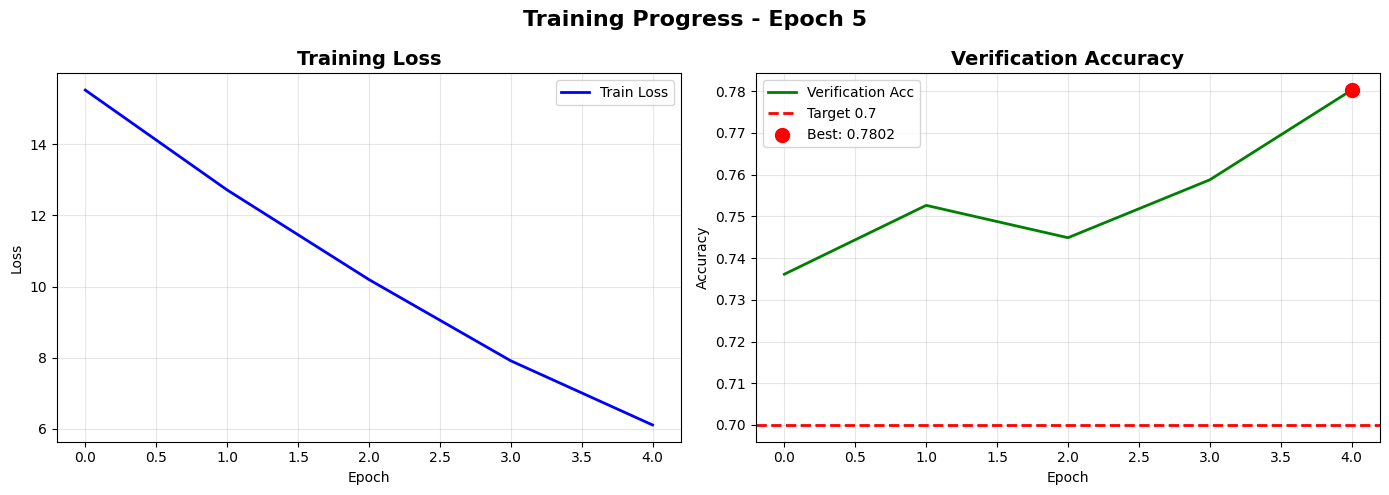


Epoch 6/30


Extracting embeddings: 100%|██████████| 16/16 [00:09<00:00,  1.74it/s]


Positive pairs (same): 4000
Negative pairs (diff): 4000
Total pairs: 8000

Results:
  Train Loss: 4.8329, Train Acc: 0.2201
  Verification Acc: 0.7762 (threshold: 0.500)
  Learning Rate: 0.009045

Epoch 7/30


Extracting embeddings: 100%|██████████| 16/16 [00:07<00:00,  2.04it/s]


Positive pairs (same): 4000
Negative pairs (diff): 4000
Total pairs: 8000

Results:
  Train Loss: 3.8870, Train Acc: 0.3205
  Verification Acc: 0.7845 (threshold: 0.500)
  Learning Rate: 0.008716
  New best model with Ver Acc: 0.7845

Epoch 8/30


...

Positive pairs (same): 4000
Negative pairs (diff): 4000
Total pairs: 8000

Results:
  Train Loss: 3.2162, Train Acc: 0.4075
  Verification Acc: 0.7875 (threshold: 0.500)
  Learning Rate: 0.008346
  New best model with Ver Acc: 0.7875

Epoch 9/30


Extracting embeddings: 100%|██████████| 16/16 [00:09<00:00,  1.71it/s]


Positive pairs (same): 4000
Negative pairs (diff): 4000
Total pairs: 8000

Results:
  Train Loss: 2.6963, Train Acc: 0.4802
  Verification Acc: 0.7887 (threshold: 0.500)
  Learning Rate: 0.007939
  New best model with Ver Acc: 0.7887

Epoch 10/30


Extracting embeddings: 100%|██████████| 16/16 [00:09<00:00,  1.77it/s]


Positive pairs (same): 4000
Negative pairs (diff): 4000
Total pairs: 8000

Results:
  Train Loss: 2.2853, Train Acc: 0.5389
  Verification Acc: 0.7957 (threshold: 0.500)
  Learning Rate: 0.007500
  New best model with Ver Acc: 0.7957


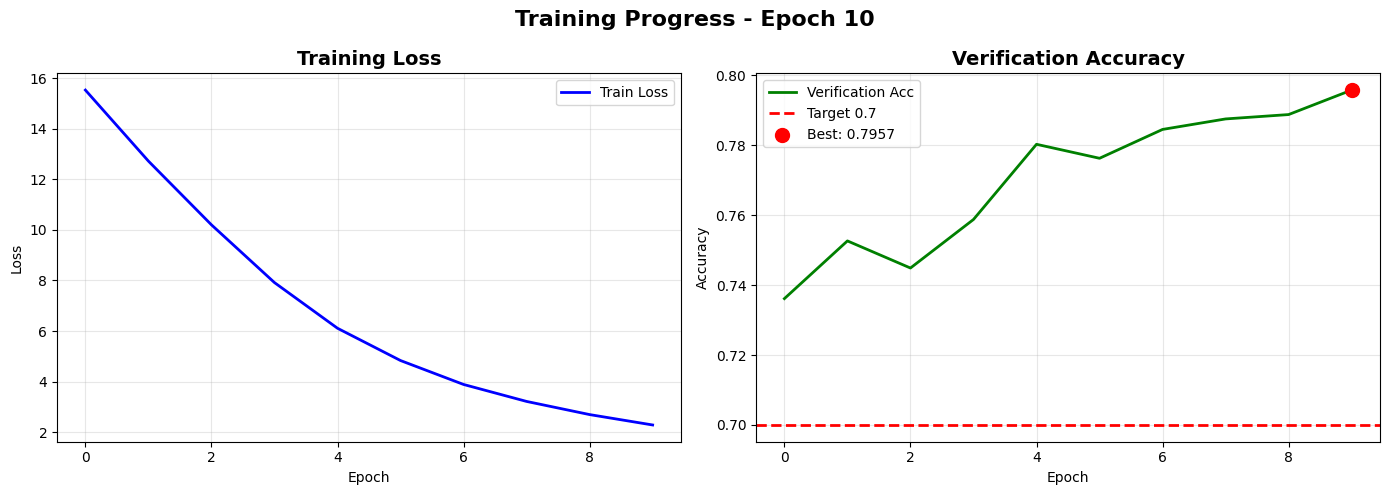


Epoch 11/30


Extracting embeddings: 100%|██████████| 16/16 [00:08<00:00,  1.83it/s]


Positive pairs (same): 4000
Negative pairs (diff): 4000
Total pairs: 8000

Results:
  Train Loss: 1.9467, Train Acc: 0.5959
  Verification Acc: 0.7914 (threshold: 0.500)
  Learning Rate: 0.007034

Epoch 12/30


Extracting embeddings: 100%|██████████| 16/16 [00:08<00:00,  1.91it/s]


Positive pairs (same): 4000
Negative pairs (diff): 4000
Total pairs: 8000

Results:
  Train Loss: 1.6579, Train Acc: 0.6484
  Verification Acc: 0.7953 (threshold: 0.500)
  Learning Rate: 0.006545

Epoch 13/30


...

Positive pairs (same): 4000
Negative pairs (diff): 4000
Total pairs: 8000

Results:
  Train Loss: 1.4276, Train Acc: 0.6956
  Verification Acc: 0.7867 (threshold: 0.500)
  Learning Rate: 0.006040

Epoch 14/30


Extracting embeddings: 100%|██████████| 16/16 [00:07<00:00,  2.03it/s]


Positive pairs (same): 4000
Negative pairs (diff): 4000
Total pairs: 8000

Results:
  Train Loss: 1.2331, Train Acc: 0.7318
  Verification Acc: 0.7894 (threshold: 0.500)
  Learning Rate: 0.005523

Epoch 15/30


Extracting embeddings: 100%|██████████| 16/16 [00:08<00:00,  1.91it/s]


Positive pairs (same): 4000
Negative pairs (diff): 4000
Total pairs: 8000

Results:
  Train Loss: 1.0592, Train Acc: 0.7680
  Verification Acc: 0.7853 (threshold: 0.500)
  Learning Rate: 0.005000


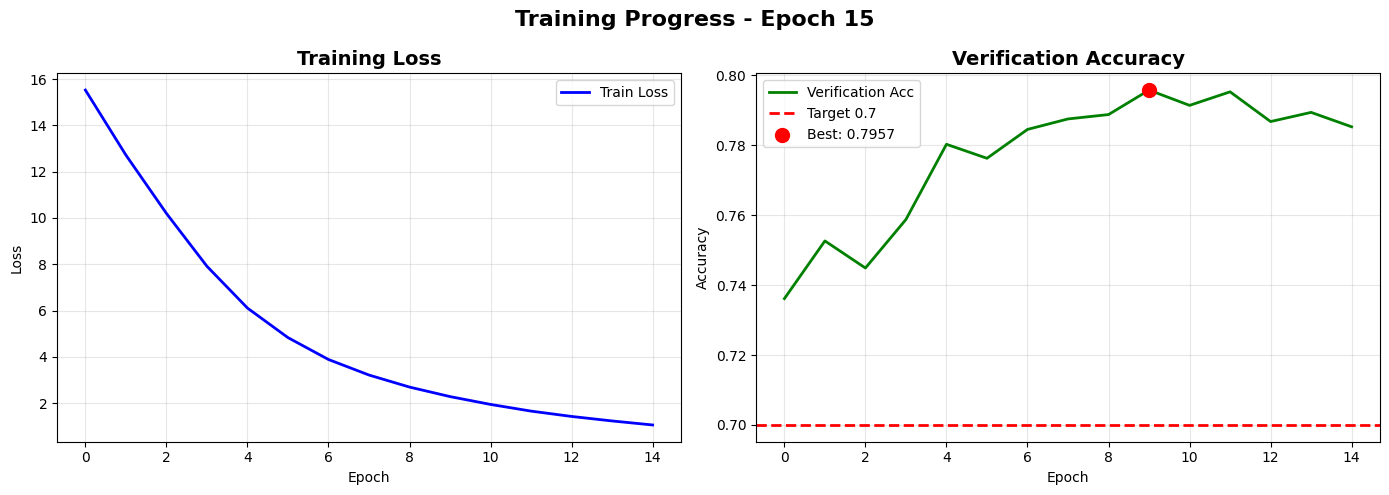


Epoch 16/30


Extracting embeddings: 100%|██████████| 16/16 [00:09<00:00,  1.76it/s]


Positive pairs (same): 4000
Negative pairs (diff): 4000
Total pairs: 8000

Results:
  Train Loss: 0.9299, Train Acc: 0.7954
  Verification Acc: 0.7819 (threshold: 0.500)
  Learning Rate: 0.004477

Epoch 17/30


Extracting embeddings: 100%|██████████| 16/16 [00:09<00:00,  1.70it/s]


Positive pairs (same): 4000
Negative pairs (diff): 4000
Total pairs: 8000

Results:
  Train Loss: 0.8002, Train Acc: 0.8256
  Verification Acc: 0.7866 (threshold: 0.500)
  Learning Rate: 0.003960

Epoch 18/30


Training:  10%|▉         | 31/312 [00:27<04:13,  1.11it/s, Loss=0.6888, Acc=85.89%]


KeyboardInterrupt: 

In [ ]:
model_arcface, train_losses_arc, train_accs_arc, ver_accs_arc = train(
    model=model_arcface,
    train_loader=train_loader,
    val_dataset=val_dataset,
    device=device,
    epochs=30,
    weight_decay=1e-4,
    loss_type='arcface',
    embedding_size=512,
    save_dir='/content/drive/MyDrive/FR_project',
    model_name='face_model_arcface'
)